C:\Users\Tobias U-05\AppData\Roaming\Python\Python313\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


9
rgba


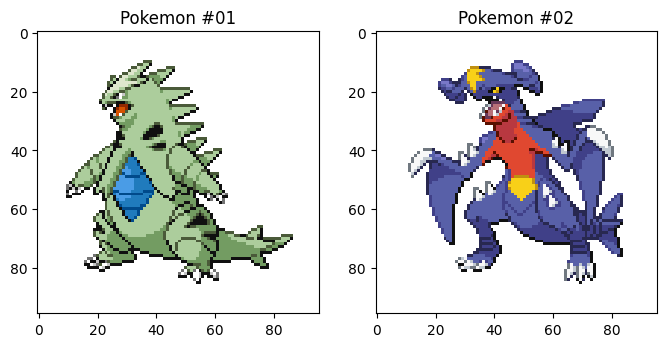

In [1]:
from random import randint, choices, sample, uniform, seed
import numpy as np
import cupy as cp
import cupyx.scipy.ndimage as scimg
import cupyx.scipy.signal as scicon
import math
import imageio.v3 as imio
from PIL import Image, ImageFile, ImageOps
import cv2

import classes.pokedex as pokedex
import classes.crossover as crossover
import classes.utils as utils


%matplotlib inline 
from matplotlib import pyplot as plt


pkd = pokedex.Pokedex(target_dex='809', score_type='rgba')
cross = crossover.Crossover([''], [])

pk1 = pkd.load_pokepng('248')
pk2 = pkd.load_pokepng('445')

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('Pokemon #01')
axis[0].imshow(cp.asnumpy(pk1), interpolation='nearest')
axis[1].set_title('Pokemon #02')
axis[1].imshow(cp.asnumpy(pk2), interpolation='nearest')

## Crossover
### Swap Simple

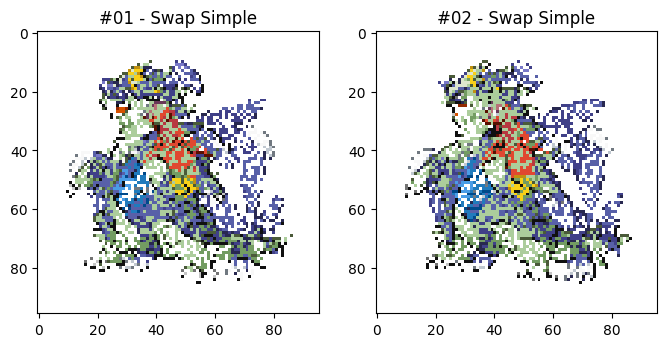

In [2]:
child_a, child_b = cross.crossover_swap_pixels(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Swap Simple')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Swap Simple')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Bisect

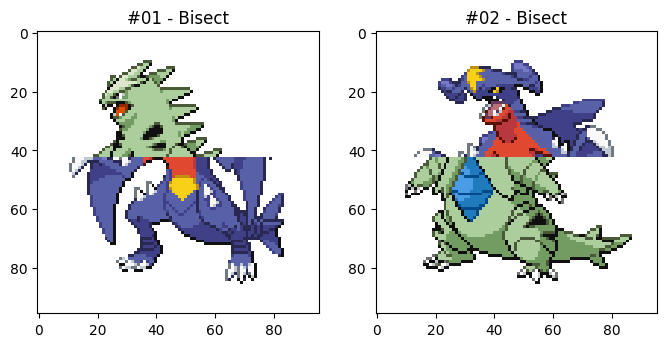

In [3]:
child_a, child_b = cross.crossover_bisect(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Bisect')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Bisect')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Chunks

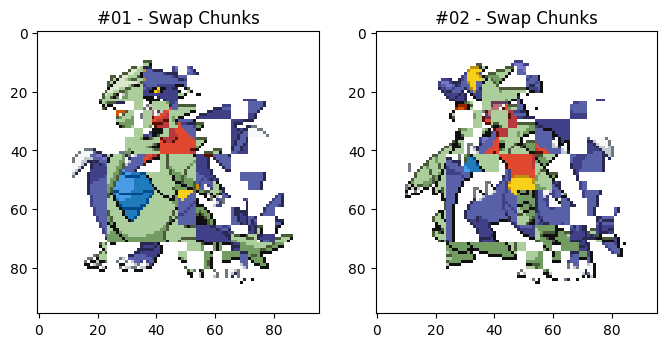

In [4]:
child_a, child_b = cross.crossover_swap_chunks(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Swap Chunks')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Swap Chunks')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Comp

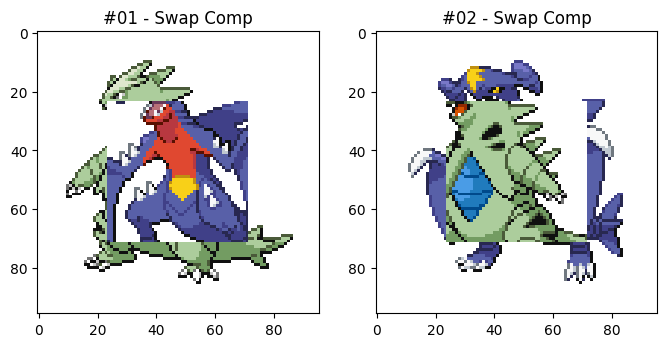

In [5]:
child_a, child_b = cross.crossover_swap_comp(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Swap Comp')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Swap Comp')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Multisect

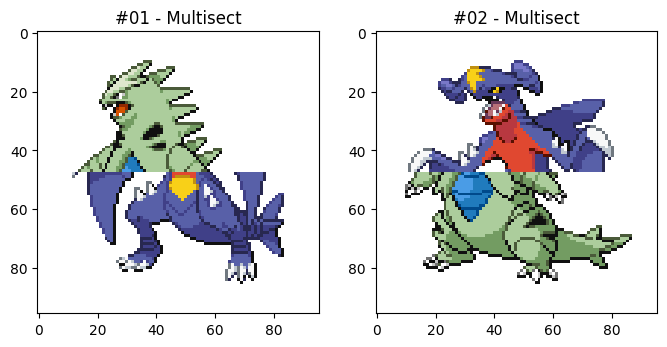

In [6]:
child_a, child_b = cross.crossover_multisect(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Multisect')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Multisect')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Channels

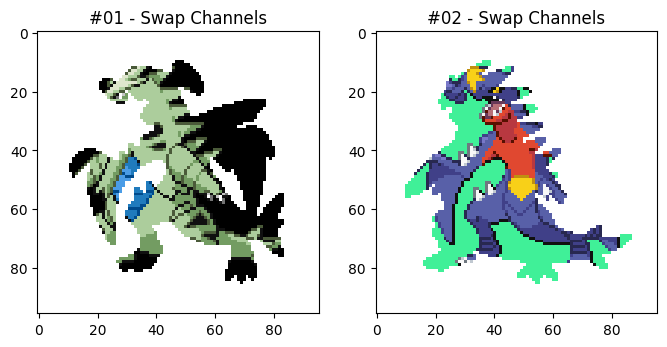

In [7]:
child_a, child_b = cross.crossover_swap_channels(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Swap Channels')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Swap Channels')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Squares

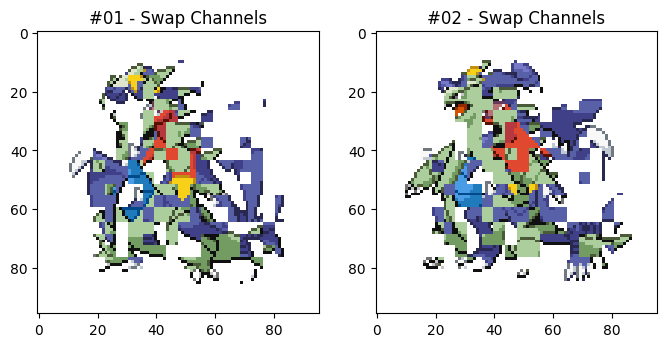

In [8]:
child_a, child_b = cross.crossover_swap_squares(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Swap Channels')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Swap Channels')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Borders

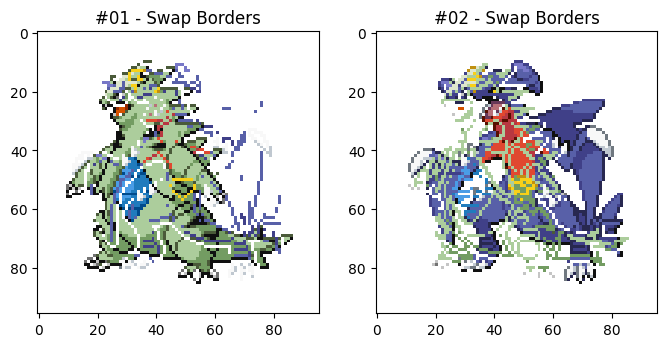

In [9]:
child_a, child_b = cross.crossover_swap_borders(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Swap Borders')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Swap Borders')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Dark_n_light

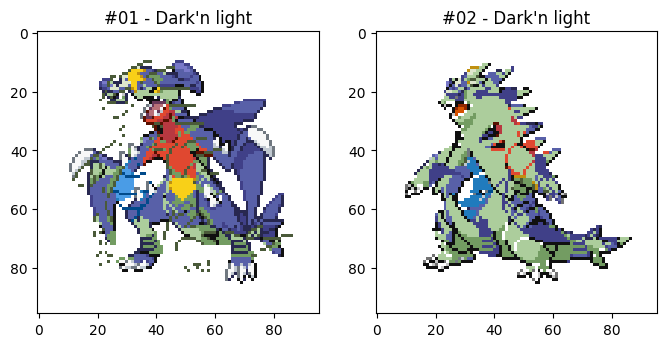

In [10]:
child_a, child_b = cross.crossover_dark_n_light(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Dark\'n light')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Dark\'n light')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Contrast

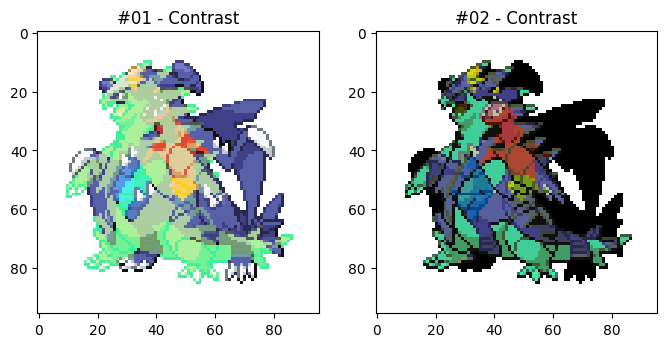

In [11]:
child_a, child_b = cross.crossover_contrast(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Contrast')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Contrast')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Even

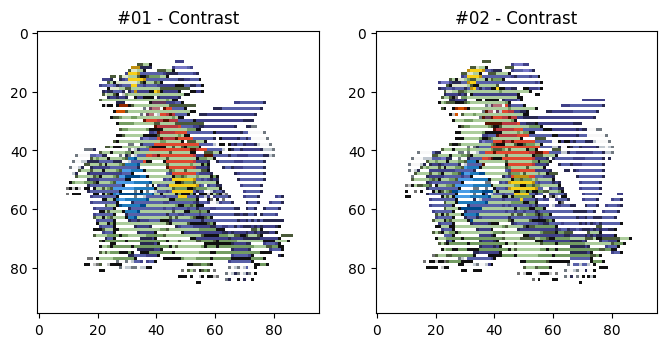

In [159]:
child_a = cp.copy(pk1)
child_b = cp.copy(pk2)

if randint(0,1):
    child_a[:,0::2] = pk2[:,0::2]
    child_b[:,0::2] = pk1[:,0::2]
else:
    child_a[0::2,:] = pk2[0::2,:]
    child_b[0::2,:] = pk1[0::2,:]

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Contrast')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Contrast')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Colors

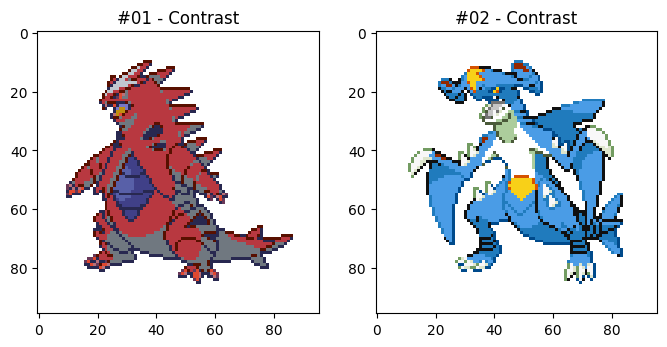

In [ ]:
def unique_colors_wrkarnd(pk):
        mk = pk[:,:,3] != 0
        flat = cp.copy(pk[mk, :3])
        flat = flat.reshape(-1, flat.shape[-1])
        #if len(flat.shape) != 2:
        #    raise ValueError("Input array must be 2D.")
        sortarr= flat[cp.lexsort(flat.T[::-1])]
        mask= cp.empty(flat.shape[0], dtype=cp.bool_)
        mask[0] = True
        mask[1:] = cp.any(sortarr[1:] != sortarr[:-1], axis=1)
        return sortarr[mask]

child_a = cp.copy(pk1)
child_b = cp.copy(pk2)

unique_1 = unique_colors_wrkarnd(pk1)
unique_2 = unique_colors_wrkarnd(pk2)

for it in range(min(len(unique_1), len(unique_2))):
    mk_a = (child_a[:,:,0] == unique_1[it][0])&(child_a[:,:,1] == unique_1[it][1])&(child_a[:,:,2] == unique_1[it][2])
    child_a[mk_a,:3] = unique_2[it][0],unique_2[it][1],unique_2[it][2]
    mk_b = (child_b[:,:,0] == unique_2[it][0])&(child_b[:,:,1] == unique_2[it][1])&(child_b[:,:,2] == unique_2[it][2])
    child_b[mk_b,:3] = unique_1[it]
    



figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Contrast')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Contrast')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Swap Catdog

### Mix Essential

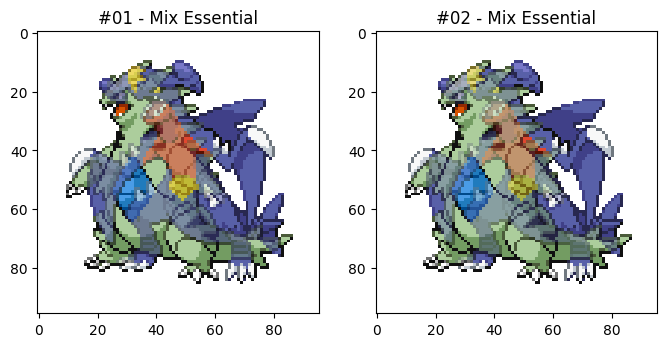

In [ ]:
child_a, child_b = cross.crossover_mix_opacity_essential(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Mix Essential')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Mix Essential')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Mix Minimize

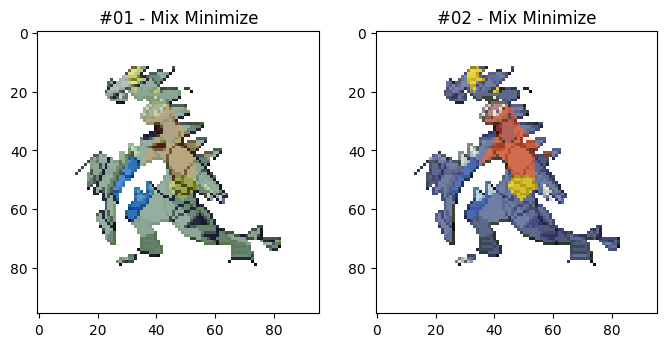

In [ ]:
child_a, child_b = cross.crossover_mix_opacity_minimize(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Mix Minimize')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Mix Minimize')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Bitwise

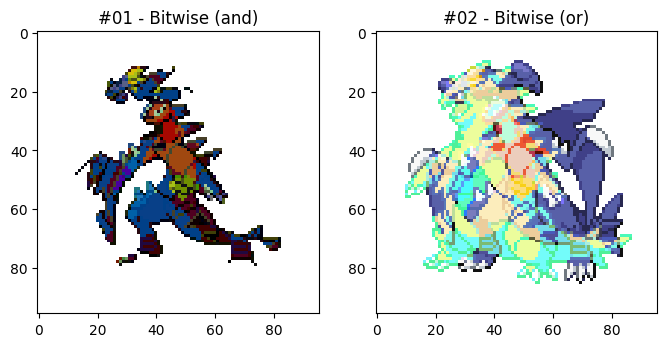

In [ ]:
child_a, child_b = cross.crossover_mix_bitwise(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Bitwise (and)')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Bitwise (or)')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Mix Subtract

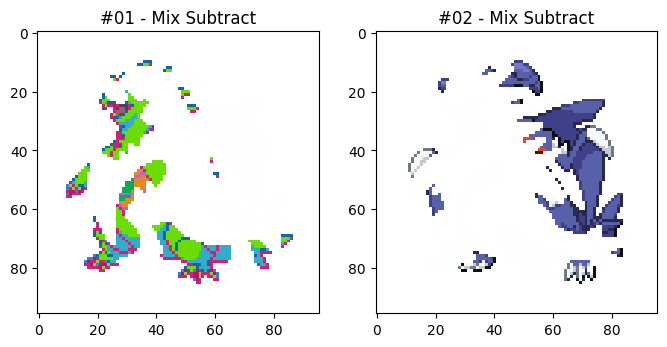

In [ ]:
child_a, child_b = cross.crossover_mix_subtract(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Mix Subtract')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Mix Subtract')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

### Difference

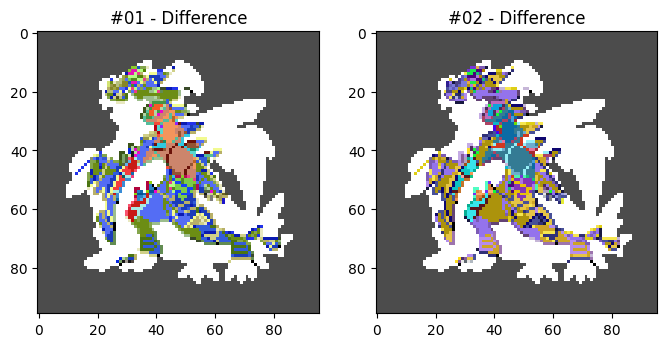

In [ ]:
child_a, child_b = cross.crossover_difference(pk1, pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Difference')
axis[0].imshow(cp.asnumpy(child_a), interpolation='nearest')
axis[1].set_title('#02 - Difference')
axis[1].imshow(cp.asnumpy(child_b), interpolation='nearest')

In [ ]:
GPU_READY = ['difference','mix_subtract']#'bitwise'
